In [1]:
%load_ext autoreload
%autoreload 2
    
import warnings
import matplotlib.pyplot as plt
import numpy as np
import glob
import xarray as xr
import xgcm
import cartopy.crs as ccrs
import sys
sys.path.insert(0, '/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/src')
from src import *
from matplotlib.colors import BoundaryNorm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

In [2]:
import cmocean
model2glodap_names = {'cfc12':'cfc12','cfc11':'cfc11','sf6':'sf6','thetao':'theta','so':'salinity'}
variable_kwargs = {
    'cfc12':{'conversion':1e12/1035,'cmap':'Greens','units':'pmol kg-1'}, #originally mol/m^3
    'cfc11':{'conversion':1e12/1035,'cmap':'PuRd','units':'pmol kg-1'},
    'sf6':{'conversion':1e12/1035 * 1e3,'cmap':'Blues','units':'fmol kg-1'},
    'theta':{'conversion':1,'cmap':cmocean.cm.thermal,'units':'degK','bins':np.arange(-2,35,0.2),'anombins':np.arange(-4,4.05,0.05)},
    'thetao':{'conversion':1,'cmap':cmocean.cm.thermal,'units':'deg C','bins':np.arange(-2,35,0.2),'anombins':np.arange(-4,4.05,0.05)},
    'salinity':{'conversion':1,'cmap':cmocean.cm.haline,'units':'psu','bins':np.arange(32,37,0.05),'anombins':np.arange(-1,1.02,0.02)}
}


In [3]:
ds_path = "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/bottom_tracers_yearly.zarr"
ds = xr.open_mfdataset(ds_path).drop_vars(["lon", "lat"])

ds = ds.assign_coords({"lon":1 * ds["geolon"].compute(), "lat":1 * ds["geolat"].compute()})
ds.lon.values[ds.lon.values < -180] = (ds.lon.values[ds.lon.values < -180] + 360) % 360

ds = ds.sel(year = slice(None, 2099))
ds = ds.where(ds.depth < -1000)

ds["sf6"] = 1 * ds["sf6"] * variable_kwargs["sf6"]["conversion"]
ds["cfc11"] = 1 * ds["cfc11"] * variable_kwargs["cfc11"]["conversion"]
ds["cfc12"] = 1 * ds["cfc12"] * variable_kwargs["cfc12"]["conversion"]

ds["sf6"].attrs["units"] = "fmol kg-1"
ds["cfc11"].attrs["units"] = "pmol kg-1"
ds["cfc12"].attrs["units"] = "pmol kg-1"

In [4]:
ds["cfc12"] = ds["cfc12"].compute()

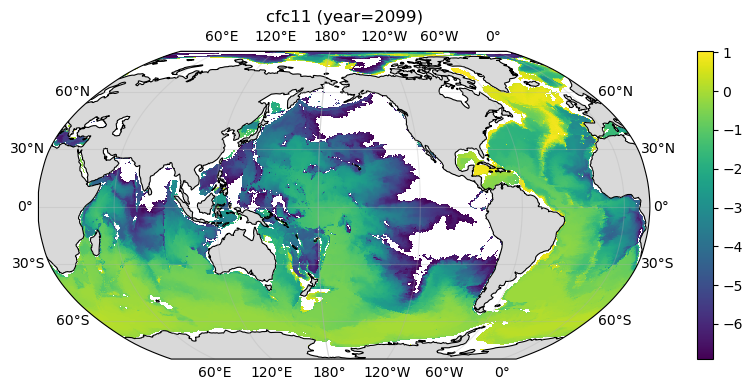

In [5]:
fig, ax = plt.subplots(
    figsize=(10, 4),
    subplot_kw=dict(projection=ccrs.Robinson(central_longitude=-165)),
)

da = ds["cfc11"].isel(expt=0).sel(year = 2090)
da = np.log(da.where(da > 0.001))

pc = ax.pcolormesh(ds["geolon"], ds["geolat"], da,transform=ccrs.PlateCarree(),shading="auto")

ax.add_feature(cfeature.LAND, facecolor="0.85", zorder=0)
ax.coastlines(linewidth=0.8)
ax.gridlines(draw_labels = True, alpha = 0.3)
ax.set_title(f"{da.name} (year={int(ds['year'].isel(year=-1).values)})")
fig.colorbar(pc)
fig.tight_layout()

In [15]:
import warnings

import matplotlib.pyplot as plt
import xarray as xr
from shapely.errors import ShapelyDeprecationWarning
from xmovie import Movie

warnings.filterwarnings(
    action='ignore',
    category=ShapelyDeprecationWarning,  # in cartopy
)
warnings.filterwarnings(
    action="ignore",
    category=UserWarning,
    message=r"No `(vmin|vmax)` provided. Data limits are calculated from input. Depending on the input this can take long. Pass `\1` to avoid this step"
)


def custom_plotfunc(ds, fig, tt, *args, **kwargs):
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson(central_longitude=180))

    pc = ax.pcolormesh(
        ds["geolon"], ds["geolat"], ds.isel(time=tt),
        transform=ccrs.PlateCarree(), vmin = -6, vmax = 1)

    ax.add_feature(cfeature.LAND, facecolor="0.85", zorder=0)
    ax.coastlines(linewidth=0.8)
    gl = ax.gridlines(draw_labels=True, alpha=0.3)
    gl.top_labels = False
    gl.right_labels = False

    ax.set_title(f"Bottom CFC-11 concentrations\n(year={ds.time[tt].values})")
    fig.colorbar(pc, ax=ax, shrink=0.4, label = "log(pmol/kg)", orientation = "horizontal", pad = 0.1)
    fig.tight_layout()

    return None, None

da = ds["cfc11"].sel(expt="control").sel(year = slice(1940, None))
da = np.log(da.where(da > 0.001)).rename({"year":"time"})

mov_custom = Movie(da, custom_plotfunc)
mov_custom.save('plots/cfc11_control_bottom_spreading.gif', remove_movie=False, progress=True, overwrite_existing = True)

  0%|          | 0/160 [00:00<?, ?it/s]

Movie created at cfc11_control_bottom_spreading.mp4
GIF created at plots/cfc11_control_bottom_spreading.gif
